In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows
import pandas as pd
import datetime
from time import sleep
from glob import glob

import encosid

SIGNAL_DT_MS = 1. # 1ms
gen = encosid.SignalGenerator("can0", 1)

## Проверка

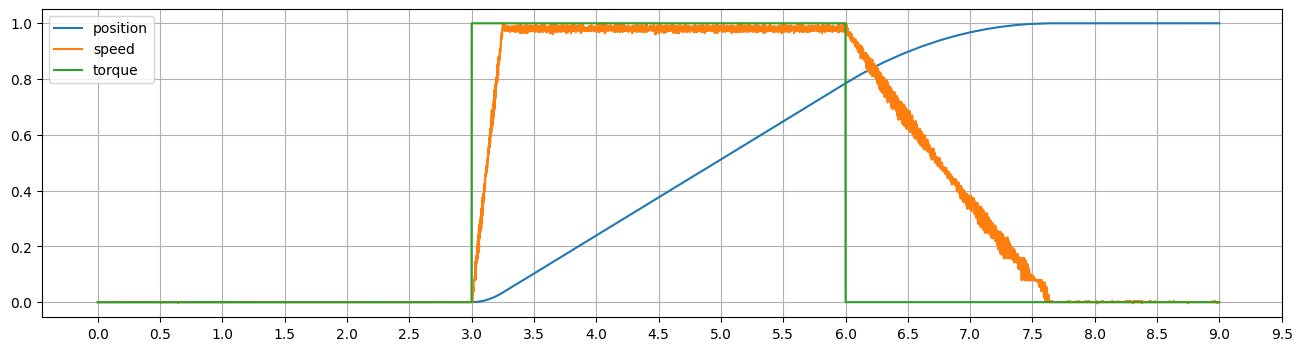

In [128]:
PULSE_LEN_S = 3
AMPLITUDE = 6

pulse_len = int(1e3 * PULSE_LEN_S / SIGNAL_DT_MS)

X = np.zeros((3*pulse_len), dtype=np.float64)
X[pulse_len:-pulse_len] = AMPLITUDE

T = np.arange(0, 3 * pulse_len) * 1e-3 * SIGNAL_DT_MS

def stitch(Y, tol=1e-2):
  Y = Y.copy()
  for i in range(len(Y) - 1):
    dy = Y[i + 1] - Y[i]
    shift = dy # TODO include remainder
    if np.abs(dy) >= 2*np.pi - tol:
      Y[i + 1:] -= shift
  return Y

Y, dY = gen.play_signal(X, SIGNAL_DT_MS)
Y = np.array(Y)
Y = stitch(Y - Y[0])
dY = np.array(dY)

plt.figure(figsize=(16, 4))
plt.plot(T, Y / np.max(Y), label="position")
plt.plot(T, dY / np.max(np.abs(dY)), label="speed")
#plt.plot(T[:-1], (Y[1:] - Y[:-1]) / SIGNAL_DT_MS * 1e3, label="speed, numeric")
plt.plot(T, X / np.max(np.abs(X)), label="torque")
plt.grid()
plt.legend()
ticks = np.arange(0, 10, .5)
plt.xticks(ticks)
plt.show()

vmax = 19.24298095703125


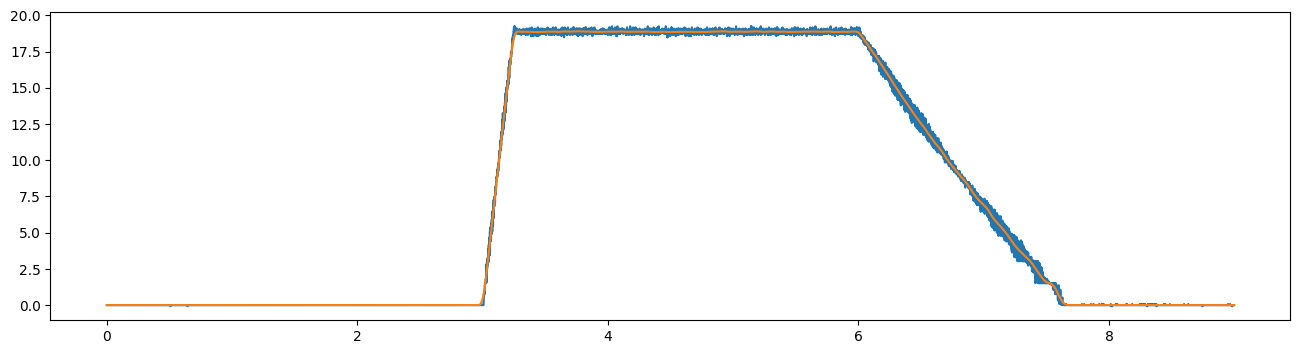

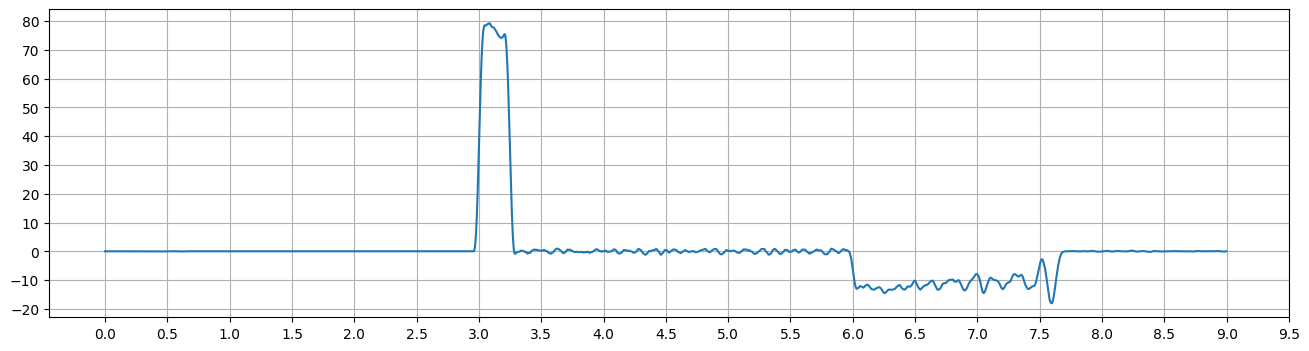

In [129]:
print(f"vmax = {np.max(np.abs(dY))}")

wlen = 100
window = windows.hann(wlen)
norm = np.sum(window) * wlen * 1e-2 * SIGNAL_DT_MS

dY_smooth = np.convolve(dY, window / norm, mode='same')
plt.figure(figsize=(16, 4))
plt.plot(T, dY)
plt.plot(T, dY_smooth)
plt.show()

ddY = (dY_smooth[2:] - dY_smooth[:-2]) * 5e2 / SIGNAL_DT_MS

plt.figure(figsize=(16, 4))
plt.plot(T[:-2], ddY)
plt.xticks(ticks)
plt.yticks(np.arange(-20, 90, 10))
plt.grid()
plt.show()

acc = (np.max(ddY) + np.min(ddY)) # rad / s^2
INERTIA_COEFF = (AMPLITUDE / acc) / 1.7

## Генерация гармоник

In [130]:
def gen_bins(M, Nmin, Nmax, rng: np.random.Generator):
  nbins = None
  if M == 1:
    nbins = 1
  else:
    nbins = rng.integers(1, M)
  
  bins = set()
  gen = lambda: rng.integers(Nmin, Nmax)
  for _ in range(nbins):
    val = gen()
    while val in bins:
      val = gen()
    bins.add(val)

  return np.array(list(bins))

def gen_random_harmonics(M, N, fmax, seed):
  fnyq = 1e3 / SIGNAL_DT_MS / 2
  F = np.linspace(-fnyq, fnyq, 2*N)

  rng = np.random.default_rng(seed=seed)

  binmax = N * (fmax / fnyq)
  if binmax > N: binmax = N

  bins = gen_bins(M, 0, binmax, rng)

  X = np.zeros((2 * N,), dtype=np.complex64)

  X.real[bins] = rng.random(len(bins))
  X.imag[bins] = rng.random(len(bins))

  X.real[2*N - bins] = X.real[bins]
  X.imag[2*N - bins] = -X.imag[bins]
  return F, X

def gen_signal(X, N):
  x = np.fft.ifft(X)
  T = 1e-3 * np.linspace(0, 2*N * SIGNAL_DT_MS, 2*N)
  return T, np.real(x) / np.max(np.abs(np.real(x)))

def extend_signal(T, x, n):
  new_x = np.ndarray((len(x) + 2*n), dtype=x.dtype)
  new_x[:n] = 0
  new_x[n: len(x) + n] = x.copy()
  new_x[-n:] = 0
  
  N = np.arange(1, n + 1)
  new_t = np.ndarray((len(x) + 2*n), dtype=T.dtype)
  new_t[:n] = -T[-1] * N[::-1] / len(T)
  new_t[n: len(T) + n] = T
  new_t[-n:] = T[-1] * (1 + N / len(T))

  return new_t, new_x

def make_torque_signal(T, v):
  dv = (v[2:] - v[:-2]) * 1e3 / (2 * SIGNAL_DT_MS)
  tau = INERTIA_COEFF * dv
  return T[1:-1], tau

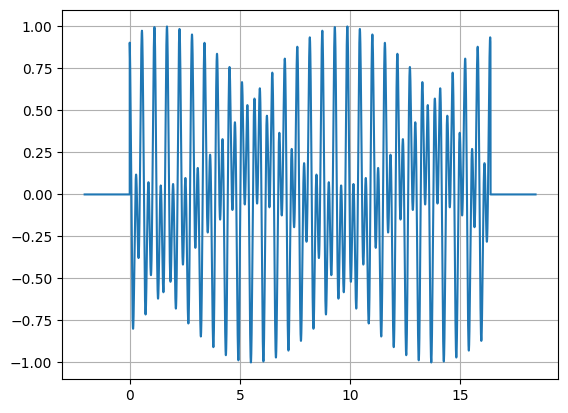

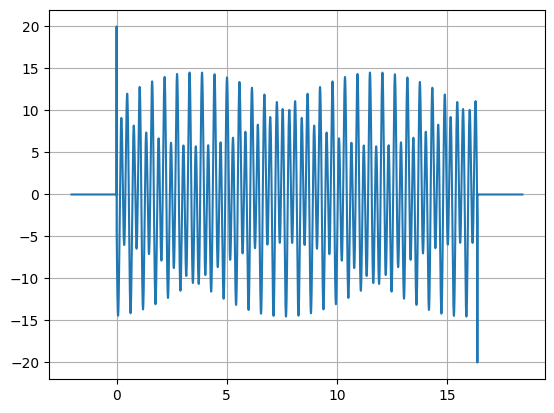

In [ ]:
VMAX = 15
TMAX = 20

N = 4096*2
F, X = gen_random_harmonics(3, N, 20, 3)
T, v = gen_signal(X, N)
T, v = extend_signal(T, v, 2048)

T, x = make_torque_signal(T, v * VMAX)
x = np.clip(x, -TMAX, TMAX)

plt.plot(T, x)
plt.grid()
plt.show()

y, dy = map(np.array, gen.play_signal(x, SIGNAL_DT_MS))
y = stitch(y - y[0])


real: 14.163612365722656, expected 14.992335319519043 [0.9447235579958352]


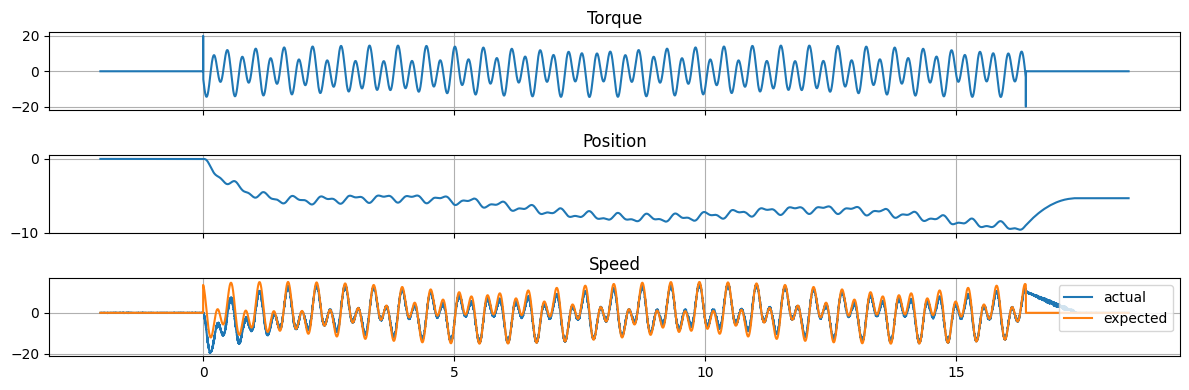

In [144]:
fig, ax = plt.subplots(3, 1, sharex=True)
fig.set_size_inches(12, 4)
ax[0].plot(T, x)
ax[0].grid()
ax[0].set_title("Torque")
ax[1].plot(T, y)
ax[1].set_title("Position")
ax[1].grid()
ax[2].plot(T, dy, label="actual")
ax[2].plot(T, (v * VMAX)[1:-1], label="expected")
ax[2].set_title("Speed")
ax[2].legend()
ax[2].grid()
fig.tight_layout()

print(f"real: {np.max(dy)}, expected {np.max(v * VMAX)} [{np.max(dy) / np.max(v * VMAX)}]")

## Ээксперимент

In [ ]:
SEEDS = range(2)
NHARMONIC = 5
NFFT = 4096*2

FMAX = 10
VMAX = 15
TMAX = 15

VELOCITY_SCALES = [0.1, 0.2, 0.4, 0.6, 0.8, 1]
STRIDE = 2 #s
DATASET = "harmonics"

for seed in SEEDS:
  for scale in VELOCITY_SCALES:
    F, X = gen_random_harmonics(NHARMONIC, N, FMAX, seed)
    T, v = gen_signal(X, N)
    T, v = extend_signal(T, v, int(STRIDE * 1e3 / SIGNAL_DT_MS))

    T, x = make_torque_signal(T, v * VMAX * scale)
    x = np.clip(x, -TMAX, TMAX)

    y, dy = map(np.array, gen.play_signal(x, SIGNAL_DT_MS))

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d-%H:%M:%S")
    name = f"seed_{seed}_as_{scale}_{timestamp}.csv"

    df = pd.DataFrame()
    df["time"] = T
    df["torque"] = x
    df["position"] = stitch(y)
    df["speed"] = dy

    df.to_csv(f"datasets/raw/{DATASET}/{name}", index=False)
    sleep(3) # let the drive stop

RuntimeError: read(): Resource temporarily unavailable

## Merge and preprocess dataset

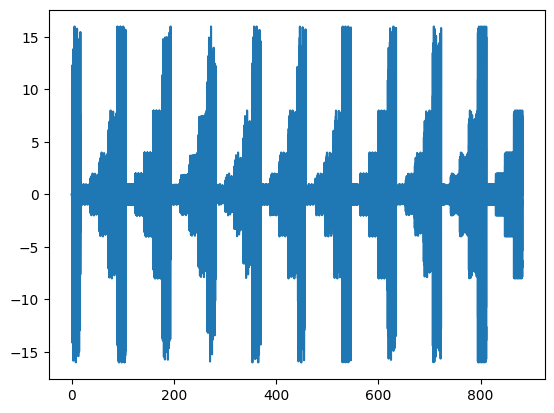

<IPython.core.display.Javascript object>

['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']


<IPython.core.display.Javascript object>

In [16]:
DATASET = 'harmonics'

df = pd.DataFrame()

pos  = [0]
vel  = [0]
act  = [0]
time = [0]

for path in sorted(glob(f"datasets/raw/{DATASET}/*")):
    df = pd.read_csv(path)

    pos.extend(df["position"])
    vel.extend(df["speed"])
    act.extend(df["torque"])
    
    time.extend(np.array(df["time"]) + SIGNAL_DT_MS + time[-1])

plt.plot(time, act)
plt.show()

%matplotlib gtk3agg
plt.plot(time, pos)
plt.xlim()
plt.show()
%matplotlib inline

'''
df["qpos_motor0_lag0"] = np.array([], dtype=np.float64)
df["qvel_motor0_lag0"] = np.array([], dtype=np.float64)
df["qact_motor0_lag0"] = np.array([], dtype=np.float64)
df["time"] = np.array([0], dtype=np.float64)
'''

from matplotlib.backends import backend_registry

# List only interactive (GUI) backends
print(backend_registry.list_builtin())
